# Multi-Task Evaluation & Inference

Evaluates trained user-specific heads and runs further experimentation.

> Generated from `Lab2_multi_task_modal.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import ast
import os
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np
import tensorflow as tf
import tensorflow.keras
import keras
from tensorflow.keras import layers
from keras.models import Sequential
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import plotly.io as plt_io
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import plotly.express as px
import itertools
from sklearn.utils import class_weight
from tensorflow.keras.models import Model
import random
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, roc_curve, auc, classification_report
%matplotlib inline

# Results

161/161 [==============================] - 0s 2ms/step


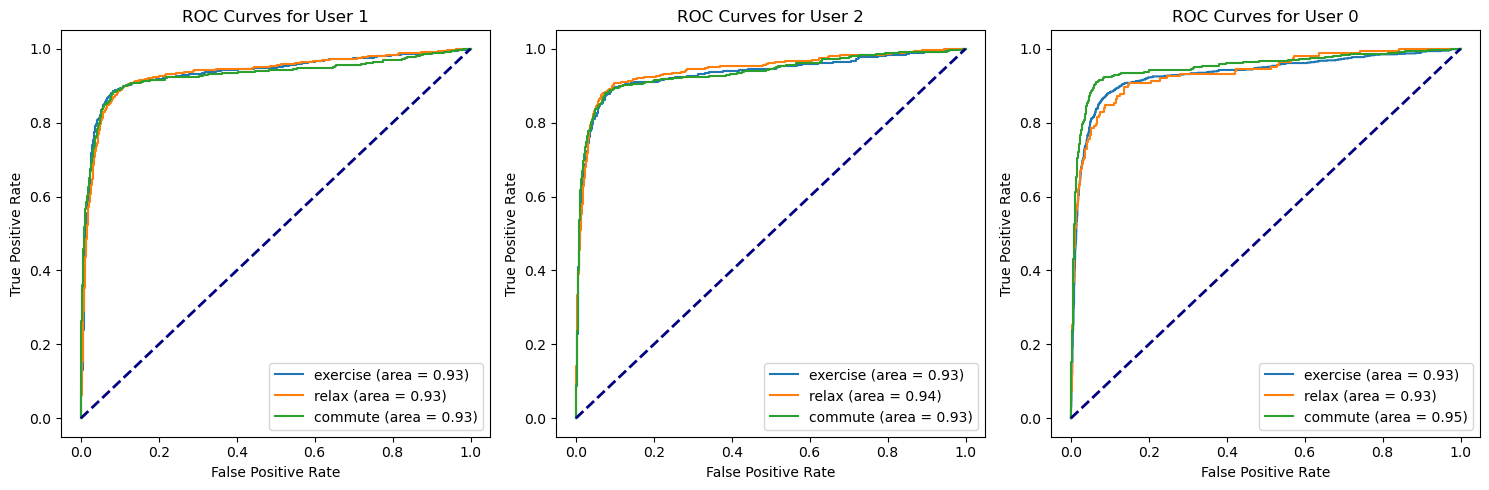

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=len(users), figsize=(15, 5))

for i, user in enumerate(users):
    # make predictions on test data
    y_pred = user_models[user].predict(X_test_dict[user])

    # loop over output nodes
    for j in range(y_test_dict[user].shape[1]):
        # calculate ROC curve and AUC score
        fpr, tpr, thresholds = roc_curve(y_test_dict[user][:, j], y_pred[:, j])
        auc_score = auc(fpr, tpr)

        # plot ROC curve
        axes[i].plot(fpr, tpr, label='{} (area = {:.2f})'.format(y_test_dict_df[user].columns[j], auc_score))

    # set plot title, legend, and axis labels
    axes[i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[i].set_title('ROC Curves for User {}'.format(user))
    axes[i].legend()
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')

# adjust spacing between plots
plt.tight_layout()

# show plots
plt.show()


161/161 [==============================] - 0s 610us/step


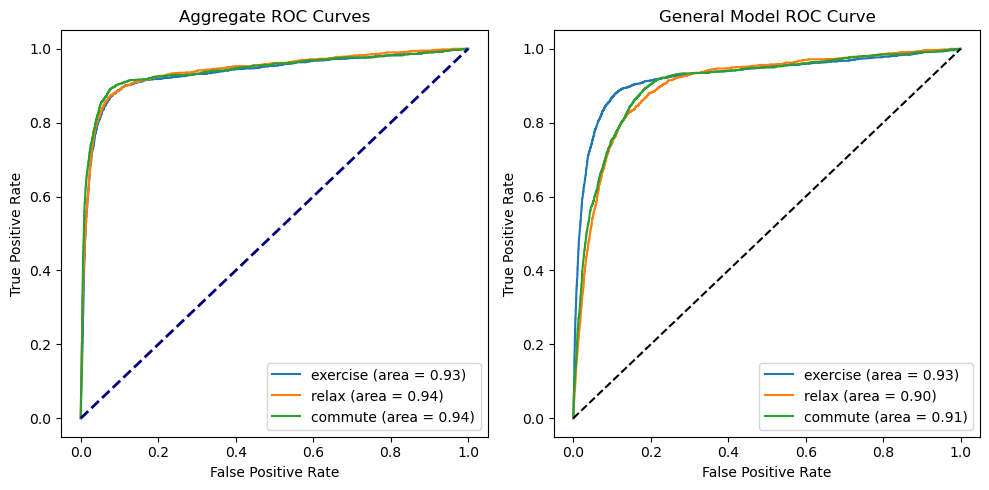

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

# plot the aggregate ROC curve on the first subplot
for j in range(y_test_dict[user].shape[1]):
    fpr, tpr, thresholds = roc_curve(np.concatenate([y_test_dict[x][:, j] for x in users]), np.concatenate([user_models[x].predict(X_test_dict[x])[:, j] for x in users]))
    auc_score = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label='{} (area = {:.2f})'.format(y_test_dict_df[user].columns[j], auc_score))
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_title('Aggregate ROC Curves')
axes[0].legend()
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')

# plot the ROC curves for each activity on the second subplot
for i in range(3):
    y_pred = general_classifier.predict(gen_X_test, verbose=0)
    fpr, tpr, thresholds = roc_curve(gen_y_test.iloc[:, i], y_pred[:, i])
    auc_score = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label='{} (area = {:.2f})'.format(gen_y_test.columns[i], auc_score))
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('General Model ROC Curve')
axes[1].legend(loc='lower right')

# adjust spacing between subplots
plt.tight_layout()

# show plot
plt.show()


When analyzing the results, we see that the auc scores with the multi-task model exceed the auc scores of the general model. This means that in general, the multi-task model is better at distinguishing between positive and negative classes.<br><br>

When breaking down each individual user (task) we see that the model performed slightly better for users 2 and 1 than it did for user 0. When we look at the auc scores for exercise, we see that all of the models including the general model, were the same with an auc score of .93. The relax and commute activities is where the scores are distinguished. For relaxing, the general model performed the worst with an auc of .90 while the multi-task model had an auc score of .93 for users 0 and 2 and an auc score of .94 for user 1. When observing the commute activity, the general model performs the worst with an auc score of .91 while the multi-task model had an auc score of .93 for users 1 and 2 and an auc score of .95 for user 0.

In [ ]:
auc_table = pd.DataFrame(columns=['User ' + str(user) for user in users]+['General Model'], index=gen_y_test.columns)

for i, user in enumerate(users):
    y_pred = user_models[user].predict(X_test_dict[user], verbose=0)
    for j in range(gen_y_test.shape[1]):
        fpr, tpr, thresholds = roc_curve(y_test_dict[user][:, j], y_pred[:, j])
        auc_table.loc[auc_table.index[j], 'User ' + str(user)] = auc(fpr, tpr)

y_pred = general_classifier.predict(gen_X_test, verbose=0)
for j in range(gen_y_test.shape[1]):
    fpr, tpr, thresholds = roc_curve(gen_y_test.iloc[:, j], y_pred[:, j])
    auc_table.loc[auc_table.index[j], 'General Model'] = auc(fpr, tpr)

# highlight the highest AUC score for each activity
auc_table = auc_table.style.apply(lambda x: ['font-weight: bold' if i == x.values.max() else '' for i in x], axis=1)
auc_table


,User 1,User 2,User 0,General Model
exercise,0.933783,0.932013,0.931465,0.925727
relax,0.933676,0.942112,0.933063,0.902224
commute,0.928222,0.934272,0.950776,0.905493


# Further Analysis

In order to further analyze my model, I will see how it performs if I regenerate the user preferences with more randomness. My initial users were generated with 10% randomness and now i will generate them with 20% randomness. I thing this is a useful analysis to see how my recommender performs wfor user with more eclectic tastes. In a real world scenario, a user's tastes vary, I want to see how my model performs with users who have more varied tastes.

In [ ]:
users_data_2 = create_users(num_users=3, randomness_percent=.2, centroid_radius=1, random_radius=None)
users_data_2.head()

,0,1,2,3,4,5,6,7,8,9,10,11,user,exercise,relax,commute
0,-0.019045,-0.004042,-0.002079,-0.016153,0.011946,0.014009,-0.017742,-0.064353,-0.853226,0.007500,0.019189,-0.675159,0,1,0,0
1,0.000837,0.021853,0.029185,-0.010078,0.015006,0.013867,-0.022846,0.835102,0.973189,-0.010224,-0.000900,0.000459,0,0,0,0
2,-0.027470,0.004121,0.011886,-0.016978,0.016231,0.019297,-0.022057,0.655998,0.113187,0.006594,0.016998,-1.024455,0,0,0,0
3,0.015544,0.024992,0.026014,-0.035301,0.054430,0.002618,-0.031899,0.835129,1.105639,-0.031586,0.000543,0.920656,0,1,0,0
4,0.012051,0.015835,0.017753,-0.020172,0.021802,0.028320,-0.035633,0.509528,0.055178,0.005396,-0.000039,0.524336,0,0,0,0


In [ ]:
#train test split with validation set
X_2 = users_data_2.drop(columns=['exercise', 'relax', 'commute'])
y_2 = users_data_2[['user', 'exercise', 'relax', 'commute']]

# split the data into training and test sets with stratification over user, exercise, relax, and commute
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=42, stratify=users_data_2[['user', 'exercise', 'relax', 'commute']])

# print the shape of the resulting sets
print("X_train shape: ", X_train_2.shape)
print("y_train shape: ", y_train_2.shape)
print("X_test shape: ", X_test_2.shape)
print("y_test shape: ", y_test_2.shape)

X_train shape:  (61824, 13)
y_train shape:  (61824, 4)
X_test shape:  (15456, 13)
y_test shape:  (15456, 4)


In [ ]:
#build a sequential model
general_classifier_2 = Sequential()
general_classifier_2.add(layers.Dense(input_dim=latent_dim, units=12, activation='relu', name='shared_input_layer'))
general_classifier_2.add(layers.Dense(input_dim=latent_dim, units=9, activation='relu', name='mid_dense_9'))
general_classifier_2.add(layers.Dense(input_dim=latent_dim, units=7, activation='relu', name='mid_dense_7'))
general_classifier_2.add(layers.Dense(input_dim=latent_dim, units=3, activation='sigmoid', name='output_layer')) 

gen_X_train_2 = X_train_2.drop(columns=['user'])
gen_y_train_2 = y_train_2.drop(columns=['user'])
gen_X_test_2 = X_test_2.drop(columns=['user'])
gen_y_test_2 = y_test_2.drop(columns=['user'])

#print the shape of the resulting sets
print("gen_X_train shape: ", gen_X_train_2.shape)
print("gen_y_train shape: ", gen_y_train_2.shape)
print("gen_X_test shape: ", gen_X_test_2.shape)
print("gen_y_test shape: ", gen_y_test_2.shape)

class_weights_2 = {}
for i in range(3):
    class_weights_2[i] = {}
    for j in range(2):
        class_count_2 = np.sum(gen_y_train_2.iloc[:, i] == j)
        class_weights_2[i][j] = class_count_2/ len(gen_y_train_2.iloc[:, i])

class_weight_dict_2 = {
    0: class_weights_2[0][0], 1: class_weights_2[0][1],
    2: class_weights_2[1][0], 3: class_weights_2[1][1],
    4: class_weights_2[2][0], 5: class_weights_2[2][1]
}

general_classifier_2.compile(optimizer='adam', loss='binary_crossentropy')
general_classifier_2.summary()
#train the model
general_classifier_2.fit(gen_X_train_2, gen_y_train_2, epochs=30, batch_size=32, class_weight=class_weight_dict_2, validation_data=(gen_X_test_2, gen_y_test_2))

gen_X_train shape:  (61824, 12)
gen_y_train shape:  (61824, 3)
gen_X_test shape:  (15456, 12)
gen_y_test shape:  (15456, 3)
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 shared_input_layer (Dense)  (None, 12)                156       
                                                                 
 mid_dense_9 (Dense)         (None, 9)                 117       
                                                                 
 mid_dense_7 (Dense)         (None, 7)                 70        
                                                                 
 output_layer (Dense)        (None, 3)                 24        
                                                                 
Total params: 367
Trainable params: 367
Non-trainable params: 0
_________________________________________________________________
Epoch 1/30
1932/1932 [==============================] - 2s 1ms/s

In [ ]:
#initializing weights
w1 = general_classifier_2.get_layer('shared_input_layer').get_weights()
w2 = general_classifier_2.get_layer('mid_dense_9').get_weights()
w3 = general_classifier_2.get_layer('mid_dense_7').get_weights()
w_output = general_classifier_2.get_layer('output_layer').get_weights()

#setting inputs
inputs = layers.Input(shape=(latent_dim,))
shared_input_layer = layers.Dense(12, activation='relu', name='shared_input_layer')(inputs)

#dictionary for moodels for each user
user_models = {}

#get the number of user
users = users_data['user'].unique()

for user in users:

    mid_dense_9 = layers.Dense(9, activation='relu', name='mid_dense_9')(shared_input_layer)
    mid_dense_7 = layers.Dense(7, activation='relu', name='mid_dense_7')(mid_dense_9)
    output_layer = layers.Dense(3, activation='sigmoid', name='output_layer')(mid_dense_7)
    model = Model(inputs=inputs, outputs=output_layer)

    user_models[user] = model

    personal1 = user_models[user].get_layer('mid_dense_9')
    personal2 = user_models[user].get_layer('mid_dense_7')
    output = user_models[user].get_layer('output_layer')

    personal1.set_weights(w2)
    personal2.set_weights(w3)
    output.set_weights(w_output)
    
    personal1.trainable = True
    personal2.trainable = True
    output.trainable = True

In [ ]:
#creating dictionaries for my train and test sets whose keys are the user and values are the data
X_train_dict = dict()
y_train_dict = dict()
X_test_dict = dict()
y_test_dict = dict()

X_train_dict_df = dict()
y_train_dict_df = dict()
X_test_dict_df = dict()
y_test_dict_df = dict()

for user in y_train['user'].unique():
    X_train_dict_df[user] = X_train[y_train['user'] == user].drop(columns=['user'])
    y_train_dict_df[user] = y_train[y_train['user'] == user].drop(columns=['user'])
    X_test_dict_df[user] = X_test[y_test['user'] == user].drop(columns=['user'])
    y_test_dict_df[user] = y_test[y_test['user'] == user].drop(columns=['user'])


for user in y_train['user'].unique():
    X_train_dict[user] = X_train[y_train['user'] == user].drop(columns=['user']).values
    y_train_dict[user] = y_train[y_train['user'] == user].drop(columns=['user']).values
    X_test_dict[user] = X_test[y_test['user'] == user].drop(columns=['user']).values
    y_test_dict[user] = y_test[y_test['user'] == user].drop(columns=['user']).values

#print the shape of the train and test sets
for user in users:
    print('User: ', user)
    print('X_train shape: ', X_train_dict[user].shape)
    print('y_train shape: ', y_train_dict[user].shape)
    print('X_test shape: ', X_test_dict[user].shape)
    print('y_test shape: ', y_test_dict[user].shape)
    print('')

User:  0
X_train shape:  (20608, 12)
y_train shape:  (20608, 3)
X_test shape:  (5152, 12)
y_test shape:  (5152, 3)

User:  1
X_train shape:  (20609, 12)
y_train shape:  (20609, 3)
X_test shape:  (5151, 12)
y_test shape:  (5151, 3)

User:  2
X_train shape:  (20607, 12)
y_train shape:  (20607, 3)
X_test shape:  (5153, 12)
y_test shape:  (5153, 3)



In [ ]:
EPOCHS = 1000

opt = {} # need separate optimizers for each output task
for x in users:
    opt[x] = Adam() # track 

train_losses = []
test_losses = []

for i in range(EPOCHS):
    
    if EPOCHS == 750: shared_input_layer_2.trainable = False

    print('Epoch',i,end=', ')
    shuffle(users) # shuffle in place operation, maybe not needed
    
    train_losses.append(step(users,opt)) # batched gradient updates

    y_mtl=[]
    yhat_mtl=[]

    valid_losses = {}
    for x in users:
        # test on data, for tracking
        yhat_mlp = user_models[x].predict(X_test_dict[x],verbose=0)
        y_mtl.append(y_test_dict[x].ravel())
        yhat_mtl.append(yhat_mlp.ravel())

        # calculate loss
        valid_losses[x] = binary_crossentropy(y_test_dict[x].ravel(), yhat_mlp.ravel())

    
    valid_losses['overall'] = binary_crossentropy(np.concatenate(y_mtl), np.concatenate(yhat_mtl))
    test_losses.append(valid_losses)

    print('Train loss:',np.array(train_losses[-1]['overall']),'Valid loss:',np.array(test_losses[-1]['overall']))

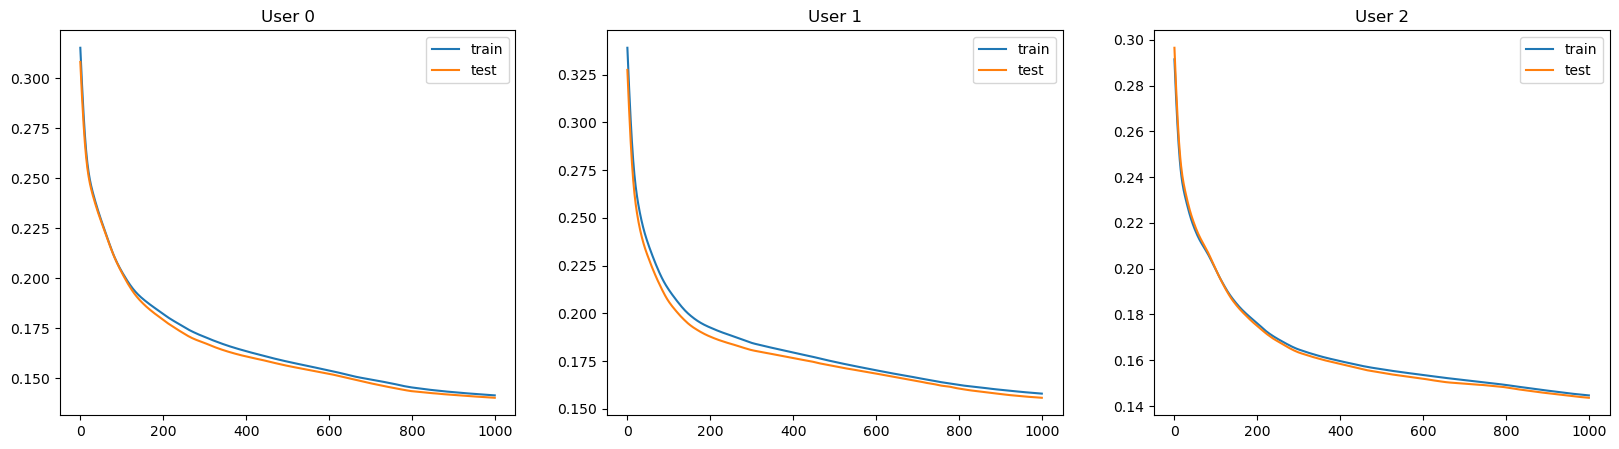

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

for user in users:
    train_loss = [train_losses[j][user] for j in range(len(train_losses))]
    test_loss = [test_losses[j][user] for j in range(len(test_losses))]
    axs[user].plot(train_loss, label='train')
    axs[user].plot(test_loss, label='test')
    axs[user].set_title('User ' + str(user))
    axs[user].legend()

plt.show()

162/162 [==============================] - 0s 589us/step


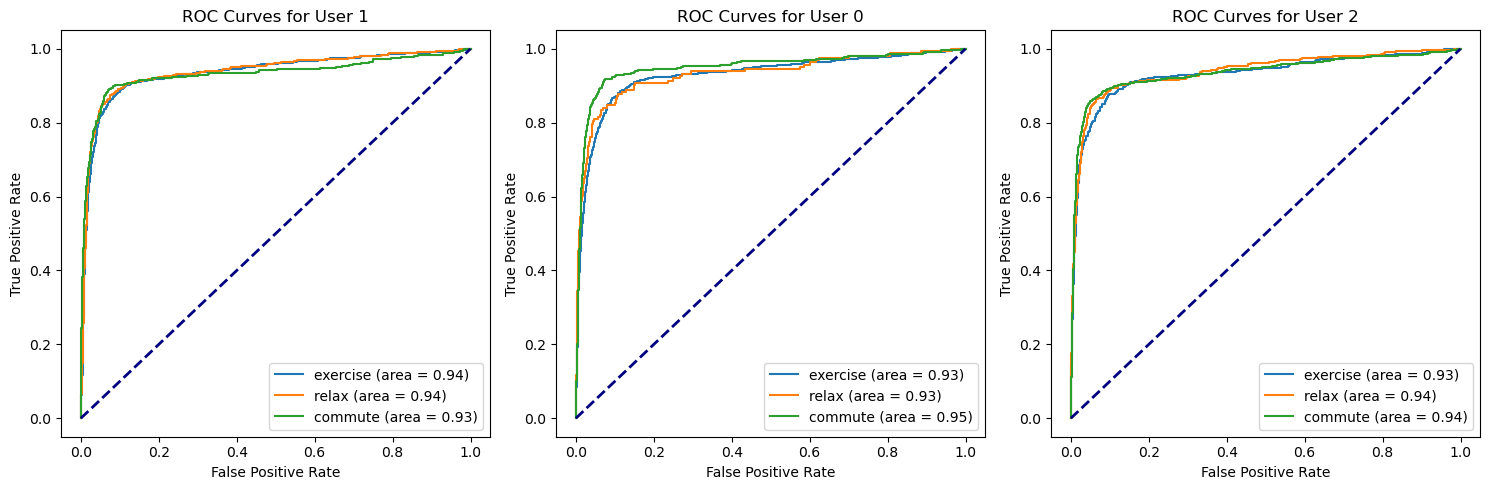

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=len(users), figsize=(15, 5))

for i, user in enumerate(users):
    # make predictions on test data
    y_pred = user_models[user].predict(X_test_dict[user])

    # loop over output nodes
    for j in range(y_test_dict[user].shape[1]):
        # calculate ROC curve and AUC score
        fpr, tpr, thresholds = roc_curve(y_test_dict[user][:, j], y_pred[:, j])
        auc_score = auc(fpr, tpr)

        # plot ROC curve
        axes[i].plot(fpr, tpr, label='{} (area = {:.2f})'.format(y_test_dict_df[user].columns[j], auc_score))

    # set plot title, legend, and axis labels
    axes[i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[i].set_title('ROC Curves for User {}'.format(user))
    axes[i].legend()
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')

# adjust spacing between plots
plt.tight_layout()

# show plots
plt.show()

The auc scores for this model with twice the randomness are almost the same as the scores in my previous model. This is a good sign that my model generalizes well to different user preferences. It would be interesting to train my model with varyiing randomness among the users to see how it performs with different types of users trained together.

In [ ]:
#export this notebook to html
!jupyter nbconvert --to html /Users/eliasmann/Documents/contextRec/Lab2_multi_task_modal.ipynb



[NbConvertApp] Converting notebook /Users/eliasmann/Documents/contextRec/Lab2_multi_task_modal.ipynb to html
/Users/eliasmann/opt/anaconda3/envs/newMlEnv/lib/python3.10/site-packages/nbconvert/filters/widgetsdatatypefilter.py:71: UserWarning: Your element with mimetype(s) dict_keys(['application/vnd.plotly.v1+json']) is not able to be represented.
  warn(
[NbConvertApp] Writing 2754965 bytes to /Users/eliasmann/Documents/contextRec/Lab2_multi_task_modal.html
